In [ ]:
!pip3 install openpyxl
!pip3 install llama-cpp-python
!pip3 install tqdm
!pip3 install --upgrade jupyter ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [ ]:
import os
import re
import json
import random
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset as TorchDataset
from transformers import (
    AutoModel, AutoConfig, AutoTokenizer,
    AutoModelForCausalLM, BitsAndBytesConfig,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix
)
from sklearn.model_selection import StratifiedGroupKFold


# -------------------------------------------------------
# 2a. Reproducibility: lock all random number generators
# -------------------------------------------------------
def set_all_seeds(seed=42):
    """Locks down all randomness for exact reproducibility across runs."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    transformers.set_seed(seed)
    print(f"Global seed set to: {seed}")

set_all_seeds(42)

# -------------------------------------------------------
# 2b. Device selection (MPS for Apple Silicon, else CPU)
# -------------------------------------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Global seed set to: 42
Using device: mps


---
# PHASE 1 — DATA PREPROCESSING
---
# 3. Preprocess VeraArab Dataset
Load the VeraArab Excel file, clean Arabic text (remove URLs, mentions, extra whitespace), normalise labels to binary {0: Fake, 1: Real}, and export as JSONL.

In [ ]:


def clean_arabic_text(text):
    """Removes noise, URLs, and extra spaces from Arabic text."""
    if not isinstance(text, str):
        return ""
    
    
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    
    text = re.sub(r'@[\w_]+', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def normalize_labels(label):
    """Converts string labels from Excel into integer 0 and 1."""
    if pd.isna(label): return None
    
    label_str = str(label).strip().lower()
    
    if label_str in ['0', 'fake', 'false', 'شائعة', 'كاذب', 'مفبرك']:
        return 0
    
    elif label_str in ['1', 'real', 'true', 'حقيقة', 'صحيح', 'صادق']:
        return 1
    else:
        return None

print("⏳ Loading original VeraArab Excel file...")

df = pd.read_excel("PATH_TO_VERAARAB_dataset.xlsx")

print(f"✅ Loaded! Found {len(df)} rows. Columns found: {df.columns.tolist()}")

TEXT_COLUMN = "text_arabic"  
LABEL_COLUMN = "label" 

print("🧹 Cleaning text and standardizing labels...")

df['cleaned_text'] = df[TEXT_COLUMN].apply(clean_arabic_text)
df['std_label'] = df[LABEL_COLUMN].apply(normalize_labels)


df = df.dropna(subset=['cleaned_text', 'std_label'])
df = df[df['cleaned_text'] != ""]


output_path = "data/processed/veraarab_clean.jsonl"
print(f"💾 Saving cleaned data to {output_path}...")

with open(output_path, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        # Saving with both "text" and "label" keys so your training script reads it perfectly
        record = {
            "text": row['cleaned_text'],
            "label": int(row['std_label'])
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"🎉 Done! Successfully saved {len(df)} clean samples.")

⏳ Loading original VeraArab Excel file...
✅ Loaded! Found 20084 rows. Columns found: ['tweet_id', 'possibly_sensitive', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'bookmark_count', 'impression_count', 'user_id', 'lang', 'annotations_text', 'annotations_type', 'hashtags', 'mentions', 'urls', 'urls_titles', 'urls_desc', 'context_domain', 'context_domain_desc', 'context_entity', 'context_entity_desc', 'copyright', 'withheld_country_codes', 'created_at', 'is_edit_eligible', 'text', 'reply_settings', 'label', 'user_created_at', 'user_description', 'user_description_urls', 'user_description_hashtags', 'user_description_mentions', 'location', 'protected', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'user_like_count', 'verified', 'claim_id', 'text_arabic', 'text_length', 'emojis', 'emojis_count', 'emojis_total_count', 'annotations_count', 'organizations', 'organizations_count', 'persons', 'persons_count', 'places', 'places_count', 'products', 'product

# 4. Preprocess AFND Dataset
Iterate over the raw AFND source folders, resolve credibility labels from `sources.json`, filter out undecided sources and short articles (< 30 chars), and export a single clean JSONL file.

In [2]:
import os
import json
from tqdm import tqdm

RAW_DIR = "data/raw/Dataset"
SOURCES_FILE = "data/raw/sources.json"
OUTPUT_FILE = "data/processed/afnd_clean.jsonl"

def load_source_labels():
    with open(SOURCES_FILE, "r", encoding="utf-8") as f:
        sources = json.load(f)
    return sources  # {"source_1": "credible", ...}

def preprocess():
    sources = load_source_labels()
    out = open(OUTPUT_FILE, "w", encoding="utf-8")

    article_id = 0

    for source_folder in tqdm(os.listdir(RAW_DIR)):
        src_path = os.path.join(RAW_DIR, source_folder, "scraped_articles.json")
        if not os.path.exists(src_path):
            continue

        label_raw = sources.get(source_folder)

        # Skip undecided sources
        if label_raw == "undecided":
            continue

        # Convert to binary labels
        label = 1 if label_raw == "credible" else 0

        with open(src_path, "r", encoding="utf-8") as f:
            articles = json.load(f)
            # print(articles) # Removed print for clean execution

        # --- MODIFICATION 1: Correctly access the list of articles ---
        if isinstance(articles, dict) and 'articles' in articles:
            article_list = articles['articles']
        elif isinstance(articles, list):
            article_list = articles
        else:
            print(f"Skipping {src_path}: unexpected JSON structure.")
            continue

        for art in article_list:
            # --- MODIFICATION 2: Fix getstr to use standard dict.get() ---
            text = art.get("text", "").strip()
            title = art.get("title", "").strip()

            if len(text) < 30:
                continue  # skip empty or tiny articles

            record = {
                "id": article_id,
                "source": source_folder,
                "label": label,
                "title": title,
                "text": text
            }

            out.write(json.dumps(record, ensure_ascii=False) + "\n")
            article_id += 1

    out.close()
    print("DONE. Written:", OUTPUT_FILE)

if __name__ == "__main__":
    preprocess()

100%|██████████| 135/135 [00:10<00:00, 12.61it/s]

DONE. Written: data/processed/afnd_clean.jsonl


# 5. Verify Preprocessed Data
Quick sanity check: load the cleaned AFND JSONL and report total sample count.

In [ ]:
DATA_PATH = OUTPUT_FILE  # change if located somewher

data = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

len(data)


374532

# 7. GPU-Accelerated Augmentation Pipeline (HuggingFace Transformers)
Alternative augmentation path using HuggingFace Transformers with 8-bit quantisation via `bitsandbytes`.

Processes samples in batches, generating two augmentation types per sample:
- **(a) Dialectal paraphrase** — rewrite into a randomly selected Arabic dialect
- **(b) Adversarial rewrite** — rephrase with completely different style

Writes augmented triplets (original + dialect + adversarial) to JSONL.

In [ ]:
import random
import json
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


MODEL_ID = "QCRI/Fanar-1-9B-Instruct"
BATCH_SIZE = 8 # Lowered slightly for 8-bit precision safety

print("Loading model in 8-bit precision for maximum accuracy on RTX 5090...")

# Use 8-bit instead of 4-bit. It fits in 16GB VRAM and makes the model MUCH smarter.
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.unk_token or tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()

# ==========================================
#   2. BATCH GENERATION ENGINE
# ==========================================
def generate_batched(prompts, max_new_tokens=100, temperature=0.6): # Increased max_new_tokens
    # Added max_length to truncation to prevent it from cutting the prompt itself!
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(model.device)
    
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id 
    
    input_lengths = inputs['input_ids'].shape[1]
    generated_tokens = outputs[:, input_lengths:]
    decoded_outputs = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
    
    return [text.split("</OUTPUT>")[0].replace("<OUTPUT>", "").strip() for text in decoded_outputs]

# ==========================================
#   3. DATA PROCESSING LOOP
# ==========================================
INPUT_FILE = "veraarab_clean.jsonl"
OUTPUT_FILE = "veraarab_augmented_5k.jsonl"
TARGET_SAMPLES = 2500

zeros, ones = [], []
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        item = json.loads(line)
        if item["label"] == 0: zeros.append(item)
        elif item["label"] == 1: ones.append(item)

# Balance dataset
random.seed(42)
random.shuffle(zeros)
random.shuffle(ones)

samples = zeros[:TARGET_SAMPLES] + ones[:TARGET_SAMPLES]
random.shuffle(samples)

print(f"Total balanced samples to process: {len(samples)}")
with open(OUTPUT_FILE, "w", encoding="utf-8") as f: pass

dialects = ["المغربية", "الجزائرية", "التونسية", "المصرية", "السورية", "اللبنانية", "الخليجية"]

for i in tqdm(range(0, len(samples), BATCH_SIZE), desc="Processing Batches"):
    batch_samples = samples[i : i + BATCH_SIZE]
    
    dialect_prompts, adv_prompts, selected_dialects = [], [], []
    
    for item in batch_samples:
        text = item.get("text", item.get("title", ""))
        dialect = random.choice(dialects)
        selected_dialects.append(dialect)
        
        dialect_prompts.append(f"[INST]<<SYS>>\nأنت نموذج لغوي متخصص في اللهجات العربية.\nمهمتك: إعادة صياغة النص المعطى إلى اللهجة {dialect} فقط.\n- ممنوع إضافة أي ملاحظة أو شرح\n- الإخراج يجب أن يكون بين الوسمين <OUTPUT> و </OUTPUT> فقط.\n<<SYS>>[/INST]\nأعد كتابة النص التالي باللهجة {dialect} حصراً:\nالنص:\n{text}\nالإخراج داخل <OUTPUT>:\n<OUTPUT>")
        
        adv_prompts.append(f"[INST]<<SYS>>\nأنت نموذج لغوي متخصص في إعادة صياغة النصوص باحترافية.\nمهمتك الوحيدة: إعادة كتابة النص بأسلوب مختلف تماماً (Adversarial Rewrite) مع الحفاظ على:\n1. نفس اللغة واللهجة الأصلية.\n2. كافة الحقائق والمعلومات بدقة 100%.\nالإخراج يجب أن يكون بين الوسمين: <OUTPUT> ... </OUTPUT>\n<<SYS>>[/INST]\nأعد كتابة النص التالي بأسلوب مختلف بنفس اللغة:\nالنص:\n{text}\nالإخراج داخل <OUTPUT> فقط:\n<OUTPUT>")

    try:
        # Pass the prompts to the fixed generator
        dialect_results = generate_batched(dialect_prompts, temperature=0.6)
        adv_results = generate_batched(adv_prompts, temperature=0.5)
        
        with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
            for idx, item in enumerate(batch_samples):
                label = item["label"]
                orig_text = item.get("text", item.get("title", ""))
                
                # Added an ID so you don't leak data during Train/Test splitting later!
                story_id = f"batch_{i}_idx_{idx}"
                
                batch_records = [
                    {"id": story_id, "text": orig_text, "label": label, "type": "original"},
                    {"id": story_id, "text": dialect_results[idx], "label": label, "type": "dialect", "dialect_name": selected_dialects[idx]},
                    {"id": story_id, "text": adv_results[idx], "label": label, "type": "adversarial"}
                ]
                
                for record in batch_records:
                    f.write(json.dumps(record, ensure_ascii=False) + "\n")
                    
    except Exception as e:
        print(f"\nError in batch {i}: {e}. Skipping this chunk.")
        continue

---
# PHASE 3 — CLASSIFICATION EXPERIMENTS (AFND Dataset)
---
# 8. Shared Components: Model Architecture, Dataset Class & Training Loop

All components shared across Tests A–D are defined here:

| Component | Description |
|-----------|-------------|
| `MARBERT_TriPool_CE` | MARBERTv2 backbone with CLS + Mean + Max triple pooling, 5× multi-sample dropout, and label-smoothed cross-entropy |
| `ArabicFakeNewsDataset` | PyTorch Dataset wrapper |
| `train_fold()` | Training loop with gradient accumulation, linear warmup, early stopping, and full metric tracking |
| `CONFIG` | Central hyperparameter dictionary |

# 9. AFND Test A — Baseline: Train on Original MSA, Validate on Original MSA

| | |
|---|---|
| **Train** | Original MSA |
| **Val** | Original MSA |
| **Purpose** | Establish upper-bound in-distribution performance |


🔥 TEST A - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 6 [Train]: 100%|██████████| 483/483 [01:18<00:00,  6.13it/s]


    ⏹ Early stopping at epoch 6

🔥 TEST A - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 7 [Train]: 100%|██████████| 483/483 [01:15<00:00,  6.42it/s]


    ⏹ Early stopping at epoch 7

🔥 TEST A - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 8 [Train]: 100%|██████████| 483/483 [01:16<00:00,  6.35it/s]


    ⏹ Early stopping at epoch 8

🏆 FINAL RESULTS - TEST A
  Accuracy:  82.31% ± 0.76%
  F1 Score:  82.20% ± 0.76%
  Precision: 83.12% ± 1.17%
  Recall:    82.31% ± 0.76%
  AUC Score: 91.37% ± 0.77%

✅ Master predictions saved to 'test_a_master_predictions.json'


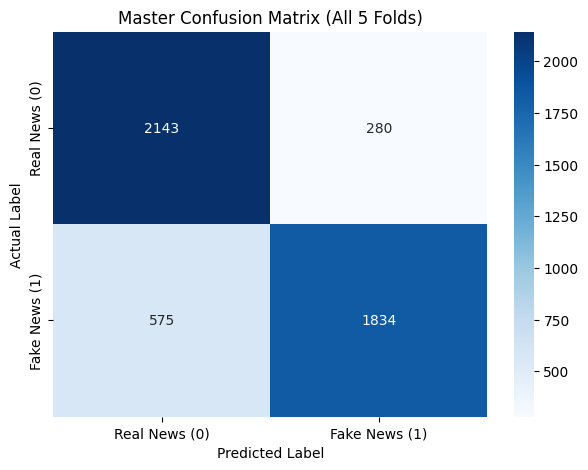

In [17]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np, json, random, gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoConfig, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm 

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)
set_all_seeds(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

CONFIG = {"model_name": "UBC-NLP/MARBERTv2", "num_labels": 2, "max_length": 80, "batch_size": 8, "grad_accum_steps": 4, 
          "num_epochs": 10, "base_lr": 2e-5, "weight_decay": 0.05, "warmup_ratio": 0.15, "max_grad_norm": 1.0, "early_stopping_patience": 3}

class MARBERT_TriPool_CE(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name))
        for param in self.bert.embeddings.parameters(): param.requires_grad = False
        for i in range(4):
            for param in self.bert.encoder.layer[i].parameters(): param.requires_grad = False
        self.dropouts = nn.ModuleList([nn.Dropout(0.2) for _ in range(5)])
        self.classifier = nn.Linear(768 * 3, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        hidden_state = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_pooled = hidden_state[:, 0, :]
        mask_expanded = attention_mask.unsqueeze(-1).expand(hidden_state.size()).float()
        mean_pooled = torch.sum(hidden_state * mask_expanded, 1) / torch.clamp(mask_expanded.sum(1), min=1e-9)
        max_pooled = torch.max(hidden_state + ((1.0 - mask_expanded) * -1e9), 1)[0]
        logits = sum(self.classifier(dropout(torch.cat([cls_pooled, mean_pooled, max_pooled], dim=1))) for dropout in self.dropouts) / 5
        loss = F.cross_entropy(logits.view(-1, 2), labels.view(-1), label_smoothing=0.1) if labels is not None else None
        return {"loss": loss, "logits": logits}

class ArabicFakeNewsDataset(TorchDataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids, self.masks, self.labels = torch.tensor(input_ids, dtype=torch.long), torch.tensor(masks, dtype=torch.long), torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return {"input_ids": self.input_ids[idx], "attention_mask": self.masks[idx], "labels": self.labels[idx]}

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
t_orig, labels_list = [], []

with open("data/processed/cleaned_balanced_data.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i % 3 == 0:
            item = json.loads(line)
            t_orig.append(item.get("text", item.get("title", ""))); labels_list.append(item["label"])

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask, y, groups = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"]), np.array(labels_list), np.arange(len(labels_list))

def train_fold(model, train_loader, val_loader, optimizer, scheduler, cfg):
    best_f1, best_acc, best_prec, best_rec, best_auc, patience = 0.0, 0.0, 0.0, 0.0, 0.0, 0
    best_preds, best_labels, best_probs = [], [], []
    
    for epoch in range(cfg["num_epochs"]):
        model.train()
        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")):
            loss = model(batch["input_ids"].to(device), batch["attention_mask"].to(device), labels=batch["labels"].to(device))["loss"] / cfg["grad_accum_steps"]
            loss.backward()
            if (step + 1) % cfg["grad_accum_steps"] == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["max_grad_norm"])
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
        
        model.eval(); all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))["logits"]
                probs = torch.softmax(logits, dim=-1)[:, 1] # Get probabilities for class 1 (Fake News) for AUC
                preds = torch.argmax(logits, dim=-1)
                
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(batch["labels"].cpu().numpy())
                
        f1 = f1_score(all_labels, all_preds, average='weighted')
        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        try: auc = roc_auc_score(all_labels, all_probs)
        except: auc = 0.0
        
        if f1 > best_f1: 
            best_f1, best_acc, best_prec, best_rec, best_auc, patience = f1, acc, prec, rec, auc, 0
            best_preds, best_labels, best_probs = all_preds, all_labels, all_probs
        else:
            patience += 1
            if patience >= cfg["early_stopping_patience"]: print(f"    ⏹ Early stopping at epoch {epoch+1}"); break
            
    return best_f1, best_acc, best_prec, best_rec, best_auc, best_preds, best_labels, best_probs

fold_results = []
master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 TEST A - FOLD {fold+1}/5\n{'='*50}")
    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[v_idx], X_orig_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - TEST A"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")

# Save predictions so you never have to retrain just to get charts!
with open("test_a_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'test_a_master_predictions.json'")

# Generate the Master Confusion Matrix
cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Master Confusion Matrix (All 5 Folds)')
plt.show()

# 10. AFND Test B — Domain Shift: Train on Original MSA, Validate on Dialect

| | |
|---|---|
| **Train** | Original MSA |
| **Val** | Dialect paraphrases |
| **Purpose** | Measure robustness degradation under dialectal domain shift |


🔥 TEST B - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 483/483 [01:15<00:00,  6.42it/s]


    ⏹ Early stopping at epoch 10

🔥 TEST B - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 7 [Train]: 100%|██████████| 483/483 [01:15<00:00,  6.43it/s]


    ⏹ Early stopping at epoch 7

🔥 TEST B - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 6 [Train]: 100%|██████████| 483/483 [01:14<00:00,  6.46it/s]


    ⏹ Early stopping at epoch 6

🏆 FINAL RESULTS - TEST B (ORIG -> DIALECT)
  Accuracy:  65.60% ± 1.00%
  F1 Score:  65.53% ± 1.04%
  Precision: 65.72% ± 0.96%
  Recall:    65.60% ± 1.00%
  AUC Score: 72.08% ± 1.42%

✅ Master predictions saved to 'test_b_master_predictions.json'


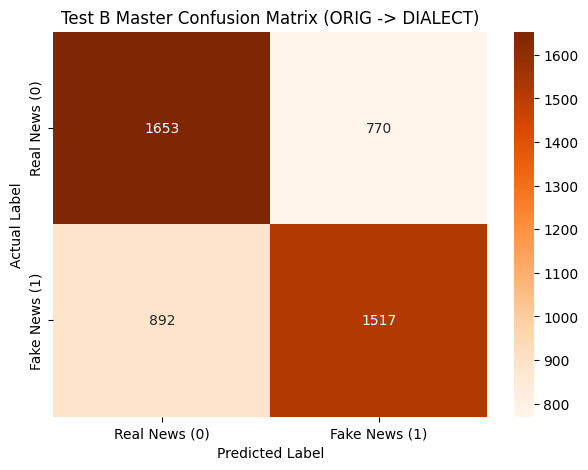

In [ ]:
t_orig, t_dial, labels_list = [], [], []
with open("data/processed/cleaned_balanced_data.jsonl", "r", encoding="utf-8") as f:
    temp_orig, temp_label = "", 0
    for i, line in enumerate(f):
        item = json.loads(line)
        text = item.get("text", item.get("title", ""))
        if i % 3 == 0: temp_orig = text; temp_label = item["label"]
        elif i % 3 == 1: t_orig.append(temp_orig); t_dial.append(text); labels_list.append(temp_label)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []
# 🟢 ADDED: Master lists for Test B
master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 TEST B - FOLD {fold+1}/5\n{'='*50}")
    # Train on ORIG, Validate on DIALECT
    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    # 🟢 CHANGED: Unpack all 8 variables returned by our upgraded train_fold
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
    # 🟢 ADDED: Stitch this fold's predictions into the Test B master lists
    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - TEST B (ORIG -> DIALECT)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")

# 🟢 ADDED: Save predictions to file
with open("test_b_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'test_b_master_predictions.json'")

# 🟢 ADDED: Plot the Confusion Matrix
cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Test B Master Confusion Matrix (ORIG -> DIALECT)')
plt.show()

# 11. AFND Test C — Adversarial Augmentation: Train on Original + Adversarial, Validate on Dialect

| | |
|---|---|
| **Train** | Original MSA + Adversarial rewrites |
| **Val** | Dialect paraphrases |
| **Purpose** | Test whether adversarial augmentation alone improves dialect robustness |



🔥 TEST C - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 8 [Train]: 100%|██████████| 966/966 [02:32<00:00,  6.31it/s]


    ⏹ Early stopping at epoch 8

🔥 TEST C - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 6 [Train]: 100%|██████████| 966/966 [02:29<00:00,  6.45it/s]


    ⏹ Early stopping at epoch 6

🔥 TEST C - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 9 [Train]: 100%|██████████| 966/966 [02:29<00:00,  6.46it/s]


    ⏹ Early stopping at epoch 9

🏆 FINAL RESULTS - TEST C (ORIG+ADV -> DIALECT)
  Accuracy:  66.10% ± 0.49%
  F1 Score:  66.03% ± 0.48%
  Precision: 66.23% ± 0.52%
  Recall:    66.10% ± 0.49%
  AUC Score: 73.12% ± 0.77%

✅ Master predictions saved to 'test_c_master_predictions.json'


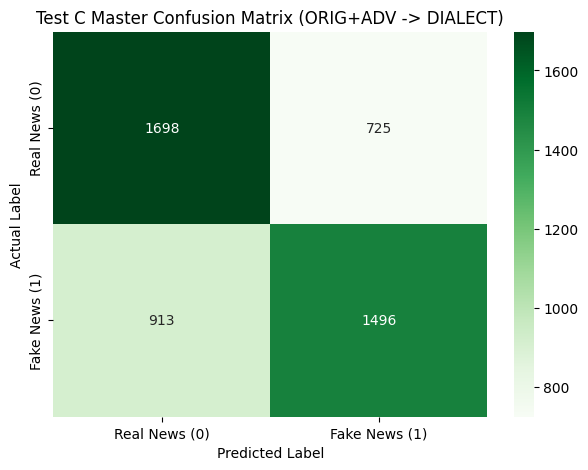

In [ ]:

t_orig, t_dial, t_adv, labels_list = [], [], [], []
with open("data/processed/cleaned_balanced_data.jsonl", "r", encoding="utf-8") as f:
    tmp_orig, tmp_dial, tmp_lbl = "", "", 0
    for i, line in enumerate(f):
        text = json.loads(line).get("text", json.loads(line).get("title", ""))
        if i % 3 == 0: tmp_orig = text; tmp_lbl = json.loads(line)["label"]
        elif i % 3 == 1: tmp_dial = text
        elif i % 3 == 2: t_orig.append(tmp_orig); t_dial.append(tmp_dial); t_adv.append(text); labels_list.append(tmp_lbl)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_adv = tokenizer(t_adv, truncation=True, padding="max_length", max_length=CONFIG["max_length"])

X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
X_adv_ids, X_adv_mask = np.array(X_adv["input_ids"]), np.array(X_adv["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []

master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 TEST C - FOLD {fold+1}/5\n{'='*50}")
    
    trn_ids = np.vstack((X_orig_ids[t_idx], X_adv_ids[t_idx]))
    trn_mask = np.vstack((X_orig_mask[t_idx], X_adv_mask[t_idx]))
    trn_y = np.concatenate((y[t_idx], y[t_idx]))

    train_loader = DataLoader(ArabicFakeNewsDataset(trn_ids, trn_mask, trn_y), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
   
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
   
    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - TEST C (ORIG+ADV -> DIALECT)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")


with open("test_c_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'test_c_master_predictions.json'")


cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Test C Master Confusion Matrix (ORIG+ADV -> DIALECT)')
plt.show()

# 12. AFND Test D — Proposed MDAF Approach: Train on Original + Dialect, Validate on Dialect


| | |
|---|---|
| **Train** | Original MSA + Dialect paraphrases |
| **Val** | Dialect paraphrases |
| **Purpose** | **Proposed dialect-aware training augmentation (MDAF)** |


🔥 TEST D - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 5 [Train]: 100%|██████████| 966/966 [02:30<00:00,  6.43it/s]


    ⏹ Early stopping at epoch 5

🔥 TEST D - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 966/966 [02:28<00:00,  6.48it/s]


    ⏹ Early stopping at epoch 10

🔥 TEST D - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 6 [Train]: 100%|██████████| 966/966 [02:32<00:00,  6.35it/s]


    ⏹ Early stopping at epoch 6

🏆 FINAL RESULTS - TEST D (ORIG+DIALECT -> DIALECT)
  Accuracy:  67.84% ± 1.37%
  F1 Score:  67.70% ± 1.39%
  Precision: 68.14% ± 1.40%
  Recall:    67.84% ± 1.37%
  AUC Score: 75.00% ± 1.40%

✅ Master predictions saved to 'test_d_master_predictions.json'


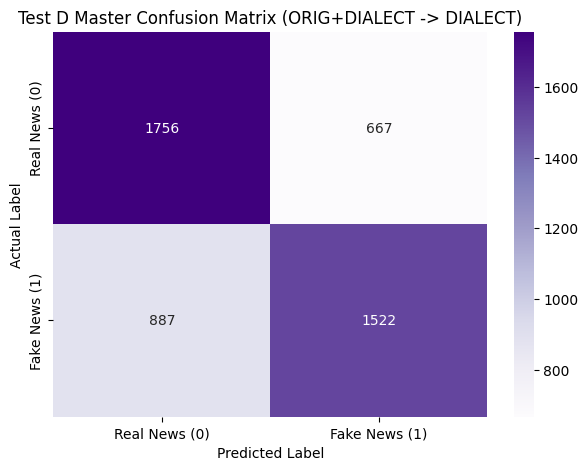

In [ ]:


t_orig, t_dial, labels_list = [], [], []
with open("data/processed/cleaned_balanced_data.jsonl", "r", encoding="utf-8") as f:
    tmp_orig, tmp_lbl = "", 0
    for i, line in enumerate(f):
        text = json.loads(line).get("text", json.loads(line).get("title", ""))
        if i % 3 == 0: tmp_orig = text; tmp_lbl = json.loads(line)["label"]
        elif i % 3 == 1: t_orig.append(tmp_orig); t_dial.append(text); labels_list.append(tmp_lbl)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []

master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 TEST D - FOLD {fold+1}/5\n{'='*50}")
 
    trn_ids = np.vstack((X_orig_ids[t_idx], X_dial_ids[t_idx]))
    trn_mask = np.vstack((X_orig_mask[t_idx], X_dial_mask[t_idx]))
    trn_y = np.concatenate((y[t_idx], y[t_idx]))

    train_loader = DataLoader(ArabicFakeNewsDataset(trn_ids, trn_mask, trn_y), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
   
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
    
    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - TEST D (ORIG+DIALECT -> DIALECT)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")


with open("test_d_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'test_d_master_predictions.json'")


cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Test D Master Confusion Matrix (ORIG+DIALECT -> DIALECT)')
plt.show()

# 9. VERA-ARAB Test A — Baseline: Train on Original MSA, Validate on Original MSA

| | |
|---|---|
| **Train** | Original MSA |
| **Val** | Original MSA |
| **Purpose** | Establish upper-bound in-distribution performance |


🔥 VERA-ARAB TEST A (ORIG->ORIG) - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.38it/s]



🔥 VERA-ARAB TEST A (ORIG->ORIG) - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.41it/s]



🔥 VERA-ARAB TEST A (ORIG->ORIG) - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.40it/s]



🏆 FINAL RESULTS - VERA-ARAB TEST A (ORIG->ORIG)
  Accuracy:  88.40% ± 1.24%
  F1 Score:  88.40% ± 1.24%
  Precision: 88.43% ± 1.25%
  Recall:    88.40% ± 1.24%
  AUC Score: 93.61% ± 0.89%

✅ Master predictions saved to 'veraarab_test_a_master_predictions.json'


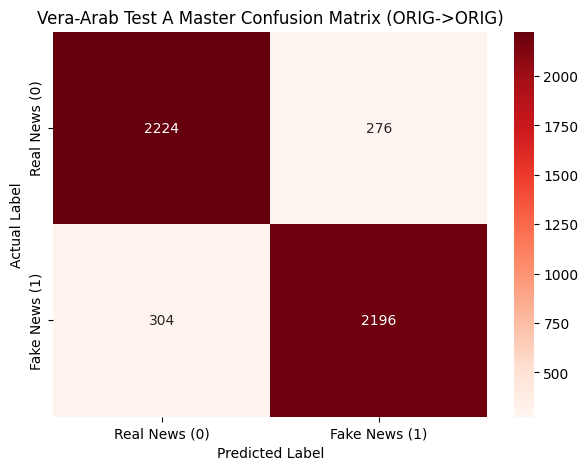

In [ ]:
t_orig, labels_list = [], []


with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i % 3 == 0:  
            item = json.loads(line)
            t_orig.append(item.get("text", item.get("title", "")))
            labels_list.append(item["label"])


X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))


fold_results = []

master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 VERA-ARAB TEST A (ORIG->ORIG) - FOLD {fold+1}/5\n{'='*50}")
    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[v_idx], X_orig_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)

    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    

    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - VERA-ARAB TEST A (ORIG->ORIG)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")


with open("veraarab_test_a_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'veraarab_test_a_master_predictions.json'")


cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Vera-Arab Test A Master Confusion Matrix (ORIG->ORIG)')
plt.show()

# 14. VERA-ARAB Test B — Domain Shift: Train on Original MSA, Validate on Dialect

| | |
|---|---|
| **Train** | Original MSA |
| **Val** | Dialect paraphrases |
| **Purpose** | Measure robustness degradation under dialectal domain shift |


🔥 VERA-ARAB TEST B (ORIG->DIALECT) - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 8 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.38it/s]


    ⏹ Early stopping at epoch 8

🔥 VERA-ARAB TEST B (ORIG->DIALECT) - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 5 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.34it/s]


    ⏹ Early stopping at epoch 5

🔥 VERA-ARAB TEST B (ORIG->DIALECT) - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:18<00:00,  6.40it/s]


    ⏹ Early stopping at epoch 10

🏆 FINAL RESULTS - VERA-ARAB TEST B (ORIG->DIALECT)
  Accuracy:  77.96% ± 2.14%
  F1 Score:  77.74% ± 2.37%
  Precision: 78.98% ± 1.44%
  Recall:    77.96% ± 2.14%
  AUC Score: 86.33% ± 0.83%

✅ Master predictions saved to 'veraarab_test_b_master_predictions.json'


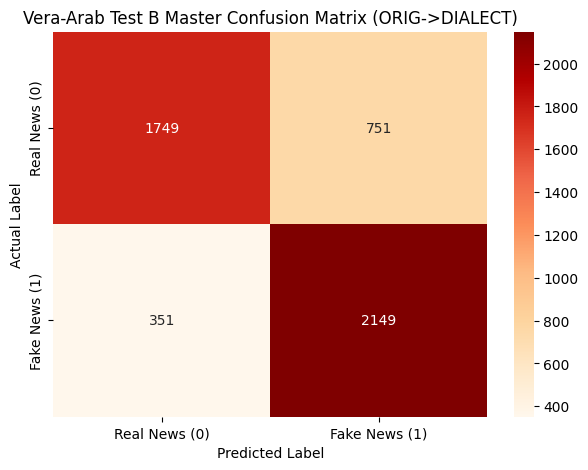

In [21]:
t_orig, t_dial, labels_list = [], [], []

with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    temp_orig, temp_label = "", 0
    for i, line in enumerate(f):
        item = json.loads(line)
        text = item.get("text", item.get("title", ""))
        if i % 3 == 0: temp_orig = text; temp_label = item["label"]
        elif i % 3 == 1: t_orig.append(temp_orig); t_dial.append(text); labels_list.append(temp_label)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []
# 🟢 ADDED: Master lists for Vera-Arab Test B
master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 VERA-ARAB TEST B (ORIG->DIALECT) - FOLD {fold+1}/5\n{'='*50}")
    # Train on ORIG, Test on DIALECT
    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    # 🟢 CHANGED: Unpack all 8 variables returned by our upgraded train_fold
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
    # 🟢 ADDED: Stitch this fold's predictions into the master lists
    master_y_true.extend(f_labels)
    master_y_pred.extend(f_preds)
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - VERA-ARAB TEST B (ORIG->DIALECT)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")

# 🟢 ADDED: Save predictions to file
with open("veraarab_test_b_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'veraarab_test_b_master_predictions.json'")

# 🟢 ADDED: Plot the Confusion Matrix
cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="OrRd", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Vera-Arab Test B Master Confusion Matrix (ORIG->DIALECT)')
plt.show()

# 15. VERA-ARAB Test C — Adversarial Augmentation: Train on Original + Adversarial, Validate on Dialect

| | |
|---|---|
| **Train** | Original MSA + Adversarial rewrites |
| **Val** | Dialect paraphrases |
| **Purpose** | Test whether adversarial augmentation alone improves dialect robustness |

In [ ]:
t_orig, t_dial, t_adv, labels_list = [], [], [], []

with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    tmp_orig, tmp_dial, tmp_lbl = "", "", 0
    for i, line in enumerate(f):
        text = json.loads(line).get("text", json.loads(line).get("title", ""))
        if i % 3 == 0: tmp_orig = text; tmp_lbl = json.loads(line)["label"]
        elif i % 3 == 1: tmp_dial = text
        elif i % 3 == 2: t_orig.append(tmp_orig); t_dial.append(tmp_dial); t_adv.append(text); labels_list.append(tmp_lbl)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_adv = tokenizer(t_adv, truncation=True, padding="max_length", max_length=CONFIG["max_length"])

X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
X_adv_ids, X_adv_mask = np.array(X_adv["input_ids"]), np.array(X_adv["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []
for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 VERA-ARAB TEST C (ORIG+ADV->DIALECT) - FOLD {fold+1}/5\n{'='*50}")
    
    
    trn_ids = np.vstack((X_orig_ids[t_idx], X_adv_ids[t_idx]))
    trn_mask = np.vstack((X_orig_mask[t_idx], X_adv_mask[t_idx]))
    trn_y = np.concatenate((y[t_idx], y[t_idx]))

    train_loader = DataLoader(ArabicFakeNewsDataset(trn_ids, trn_mask, trn_y), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)


    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - VERA-ARAB TEST C"); print("="*50)
print(f"  Accuracy: {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score: {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")


🔥 VERA-ARAB TEST C (ORIG+ADV->DIALECT) - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 1000/1000 [02:42<00:00,  6.15it/s]



🔥 VERA-ARAB TEST C (ORIG+ADV->DIALECT) - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 7 [Train]: 100%|██████████| 1000/1000 [02:34<00:00,  6.49it/s]


    ⏹ Early stopping at epoch 7

🔥 VERA-ARAB TEST C (ORIG+ADV->DIALECT) - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 1000/1000 [02:36<00:00,  6.40it/s]


    ⏹ Early stopping at epoch 10

🏆 FINAL RESULTS - VERA-ARAB TEST C
  Accuracy: 84.70% ± 1.68%
  F1 Score: 84.66% ± 1.74%


# 16. VERA_ARAB Test D — Proposed MDAF Approach: Train on Original + Dialect, Validate on Dialect

| | |
|---|---|
| **Train** | Original MSA + Dialect paraphrases |
| **Val** | Dialect paraphrases |
| **Purpose** | **Proposed dialect-aware training augmentation (MDAF)** |


🔥 VERA-ARAB TEST D (ORIG+DIALECT->DIALECT) - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 9 [Train]: 100%|██████████| 1000/1000 [02:36<00:00,  6.39it/s]


    ⏹ Early stopping at epoch 9

🔥 VERA-ARAB TEST D (ORIG+DIALECT->DIALECT) - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 1000/1000 [02:36<00:00,  6.39it/s]



🔥 VERA-ARAB TEST D (ORIG+DIALECT->DIALECT) - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 7 [Train]: 100%|██████████| 1000/1000 [02:37<00:00,  6.34it/s]


    ⏹ Early stopping at epoch 7

🏆 FINAL RESULTS - VERA-ARAB TEST D (ORIG+DIALECT->DIALECT)
  Accuracy:  85.48% ± 1.18%
  F1 Score:  85.48% ± 1.17%
  Precision: 85.51% ± 1.19%
  Recall:    85.48% ± 1.18%
  AUC Score: 90.90% ± 1.51%

✅ Master predictions saved to 'veraarab_test_d_master_predictions.json'


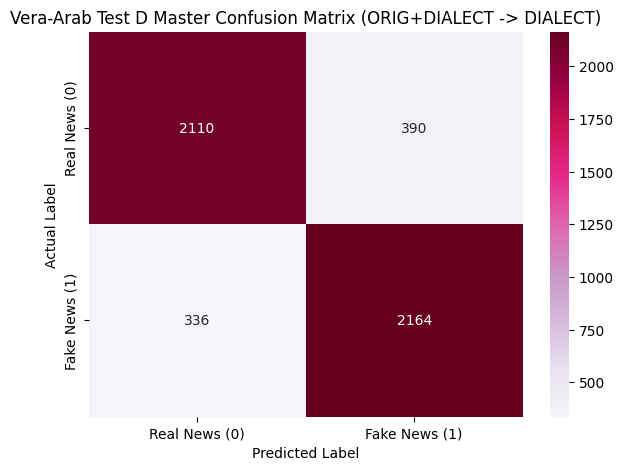

In [22]:
t_orig, t_dial, labels_list = [], [], []

with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    tmp_orig, tmp_lbl = "", 0
    for i, line in enumerate(f):
        text = json.loads(line).get("text", json.loads(line).get("title", ""))
        if i % 3 == 0: tmp_orig = text; tmp_lbl = json.loads(line)["label"]
        elif i % 3 == 1: t_orig.append(tmp_orig); t_dial.append(text); labels_list.append(tmp_lbl)

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dial, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

fold_results = []

master_y_true, master_y_pred, master_y_probs = [], [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 VERA-ARAB TEST D (ORIG+DIALECT->DIALECT) - FOLD {fold+1}/5\n{'='*50}")
    
   
    trn_ids = np.vstack((X_orig_ids[t_idx], X_dial_ids[t_idx]))
    trn_mask = np.vstack((X_orig_mask[t_idx], X_dial_mask[t_idx]))
    trn_y = np.concatenate((y[t_idx], y[t_idx]))

    train_loader = DataLoader(ArabicFakeNewsDataset(trn_ids, trn_mask, trn_y), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_TriPool_CE(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    
    f1, acc, prec, rec, auc, f_preds, f_labels, f_probs = train_fold(model, train_loader, val_loader, opt, sch, CONFIG)
    fold_results.append({"f1": f1, "acc": acc, "prec": prec, "rec": rec, "auc": auc})
    
    
    master_y_probs.extend(f_probs)
    
    del model, opt, sch, train_loader, val_loader; gc.collect(); torch.mps.empty_cache()

print("\n🏆 FINAL RESULTS - VERA-ARAB TEST D (ORIG+DIALECT->DIALECT)"); print("="*50)
print(f"  Accuracy:  {np.mean([r['acc']*100 for r in fold_results]):.2f}% ± {np.std([r['acc']*100 for r in fold_results]):.2f}%")
print(f"  F1 Score:  {np.mean([r['f1']*100 for r in fold_results]):.2f}% ± {np.std([r['f1']*100 for r in fold_results]):.2f}%")
print(f"  Precision: {np.mean([r['prec']*100 for r in fold_results]):.2f}% ± {np.std([r['prec']*100 for r in fold_results]):.2f}%")
print(f"  Recall:    {np.mean([r['rec']*100 for r in fold_results]):.2f}% ± {np.std([r['rec']*100 for r in fold_results]):.2f}%")
print(f"  AUC Score: {np.mean([r['auc']*100 for r in fold_results]):.2f}% ± {np.std([r['auc']*100 for r in fold_results]):.2f}%")


with open("veraarab_test_d_master_predictions.json", "w") as f:
    json.dump({"y_true": [int(x) for x in master_y_true], 
               "y_pred": [int(x) for x in master_y_pred], 
               "y_probs": [float(x) for x in master_y_probs]}, f)
print("\n✅ Master predictions saved to 'veraarab_test_d_master_predictions.json'")


cm = confusion_matrix(master_y_true, master_y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuRd", 
            xticklabels=["Real News (0)", "Fake News (1)"], 
            yticklabels=["Real News (0)", "Fake News (1)"])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Vera-Arab Test D Master Confusion Matrix (ORIG+DIALECT -> DIALECT)')
plt.show()

# 17. ArabFake- Vanilla Baseline Model

| | |
|---|---|
| **Train** | Original MSA |
| **Val** | A: MSA | B: Dialect


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np, json, random, gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoConfig, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm 
import copy

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)
set_all_seeds(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

CONFIG = {"model_name": "UBC-NLP/MARBERTv2", "num_labels": 2, "max_length": 80, "batch_size": 8, "grad_accum_steps": 4, 
          "num_epochs": 10, "base_lr": 2e-5, "weight_decay": 0.05, "warmup_ratio": 0.15, "max_grad_norm": 1.0, "early_stopping_patience": 3}


class MARBERT_Baseline(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name))
        for param in self.bert.embeddings.parameters(): param.requires_grad = False
        for i in range(4):
            for param in self.bert.encoder.layer[i].parameters(): param.requires_grad = False
        
        
        self.dropout = nn.Dropout(0.1) 
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        hidden_state = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        # Just grab the [CLS] token (Standard BERT practice)
        cls_pooled = hidden_state[:, 0, :] 
        
        logits = self.classifier(self.dropout(cls_pooled))
        # Removed label smoothing to make it a strictly standard baseline
        loss = F.cross_entropy(logits.view(-1, 2), labels.view(-1)) if labels is not None else None
        return {"loss": loss, "logits": logits}

class ArabicFakeNewsDataset(TorchDataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids, self.masks, self.labels = torch.tensor(input_ids, dtype=torch.long), torch.tensor(masks, dtype=torch.long), torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return {"input_ids": self.input_ids[idx], "attention_mask": self.masks[idx], "labels": self.labels[idx]}

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])


t_orig, t_dialect, labels_list = [], [], []

with open("data/processed/cleaned_balanced_data.jsonl", "r", encoding="utf-8") as f:
    lines = f.readlines()
    for i in range(0, len(lines), 3): # Assuming 0=Orig, 1=Dialect, 2=Adv
        item_orig = json.loads(lines[i])
        item_dial = json.loads(lines[i+1])
        t_orig.append(item_orig.get("text", item_orig.get("title", "")))
        t_dialect.append(item_dial.get("text", item_dial.get("title", "")))
        labels_list.append(item_orig["label"])

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dialect, truncation=True, padding="max_length", max_length=CONFIG["max_length"])

X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))["logits"]
            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
            
    f1 = f1_score(all_labels, all_preds, average='weighted')
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try: auc = roc_auc_score(all_labels, all_probs)
    except: auc = 0.0
    return acc, f1, prec, rec, auc, all_preds, all_labels, all_probs

def train_fold(model, train_loader, val_loader_A, val_loader_B, optimizer, scheduler, cfg):
    best_f1, patience = 0.0, 0
    best_model_state = None
    

    best_A_metrics = {}
    
    for epoch in range(cfg["num_epochs"]):
        model.train()
        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")):
            loss = model(batch["input_ids"].to(device), batch["attention_mask"].to(device), labels=batch["labels"].to(device))["loss"] / cfg["grad_accum_steps"]
            loss.backward()
            if (step + 1) % cfg["grad_accum_steps"] == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["max_grad_norm"])
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
        
        
        acc_A, f1_A, prec_A, rec_A, auc_A, preds_A, labels_A, probs_A = evaluate_loader(model, val_loader_A)
        
        if f1_A > best_f1: 
            best_f1, patience = f1_A, 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            best_A_metrics = {"acc": acc_A, "f1": f1_A, "prec": prec_A, "rec": rec_A, "auc": auc_A, "preds": preds_A, "labels": labels_A, "probs": probs_A}
        else:
            patience += 1
            if patience >= cfg["early_stopping_patience"]: 
                print(f"    ⏹ Early stopping at epoch {epoch+1}")
                break
                
    
    model.load_state_dict(best_model_state)
    

    acc_B, f1_B, prec_B, rec_B, auc_B, preds_B, labels_B, probs_B = evaluate_loader(model, val_loader_B)
    best_B_metrics = {"acc": acc_B, "f1": f1_B, "prec": prec_B, "rec": rec_B, "auc": auc_B, "preds": preds_B, "labels": labels_B, "probs": probs_B}
            
    return best_A_metrics, best_B_metrics

fold_results_A, fold_results_B = [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 BASELINE - FOLD {fold+1}/5\n{'='*50}")
    

    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    

    val_loader_A = DataLoader(ArabicFakeNewsDataset(X_orig_ids[v_idx], X_orig_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    val_loader_B = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_Baseline(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    metrics_A, metrics_B = train_fold(model, train_loader, val_loader_A, val_loader_B, opt, sch, CONFIG)
    
    fold_results_A.append(metrics_A)
    fold_results_B.append(metrics_B)
    
    del model, opt, sch, train_loader, val_loader_A, val_loader_B; gc.collect(); torch.mps.empty_cache()

def print_final_results(title, results):
    print(f"\n🏆 FINAL RESULTS - {title}"); print("="*50)
    print(f"  Accuracy:  {np.mean([r['acc']*100 for r in results]):.2f}% ± {np.std([r['acc']*100 for r in results]):.2f}%")
    print(f"  F1 Score:  {np.mean([r['f1']*100 for r in results]):.2f}% ± {np.std([r['f1']*100 for r in results]):.2f}%")
    print(f"  Precision: {np.mean([r['prec']*100 for r in results]):.2f}% ± {np.std([r['prec']*100 for r in results]):.2f}%")
    print(f"  Recall:    {np.mean([r['rec']*100 for r in results]):.2f}% ± {np.std([r['rec']*100 for r in results]):.2f}%")
    print(f"  AUC Score: {np.mean([r['auc']*100 for r in results]):.2f}% ± {np.std([r['auc']*100 for r in results]):.2f}%")

print_final_results("TEST A (BASELINE: ORIG -> ORIG)", fold_results_A)
print_final_results("TEST B (BASELINE: ORIG -> DIALECT)", fold_results_B)


🔥 BASELINE - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 7 [Train]: 100%|██████████| 483/483 [01:15<00:00,  6.42it/s]


    ⏹ Early stopping at epoch 7

🔥 BASELINE - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 9 [Train]: 100%|██████████| 483/483 [01:14<00:00,  6.47it/s]


    ⏹ Early stopping at epoch 9

🔥 BASELINE - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 483/483 [01:14<00:00,  6.47it/s]


    ⏹ Early stopping at epoch 10

🏆 FINAL RESULTS - TEST A (BASELINE: ORIG -> ORIG)
  Accuracy:  82.39% ± 0.74%
  F1 Score:  82.34% ± 0.74%
  Precision: 82.69% ± 0.79%
  Recall:    82.39% ± 0.74%
  AUC Score: 91.51% ± 0.74%

🏆 FINAL RESULTS - TEST B (BASELINE: ORIG -> DIALECT)
  Accuracy:  64.55% ± 0.81%
  F1 Score:  64.25% ± 0.72%
  Precision: 65.04% ± 1.10%
  Recall:    64.55% ± 0.81%
  AUC Score: 72.44% ± 0.90%


In [46]:
import torch, torch.nn as nn, torch.nn.functional as F, numpy as np, json, random, gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModel, AutoConfig, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm 
import copy

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.backends.mps.is_available(): torch.mps.manual_seed(seed)
set_all_seeds(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

CONFIG = {"model_name": "UBC-NLP/MARBERTv2", "num_labels": 2, "max_length": 80, "batch_size": 8, "grad_accum_steps": 4, 
          "num_epochs": 10, "base_lr": 2e-5, "weight_decay": 0.05, "warmup_ratio": 0.15, "max_grad_norm": 1.0, "early_stopping_patience": 3}

# 1. VANILLA BASELINE MODEL (No Tri-Pooling, No Multi-Sample Dropout)
class MARBERT_Baseline(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, config=AutoConfig.from_pretrained(model_name))
        for param in self.bert.embeddings.parameters(): param.requires_grad = False
        for i in range(4):
            for param in self.bert.encoder.layer[i].parameters(): param.requires_grad = False
        
        # Standard Single Dropout and Standard Linear Layer size (768)
        self.dropout = nn.Dropout(0.1) 
        self.classifier = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask=None, labels=None):
        hidden_state = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        # Just grab the [CLS] token (Standard BERT practice)
        cls_pooled = hidden_state[:, 0, :] 
        
        logits = self.classifier(self.dropout(cls_pooled))
        # Removed label smoothing to make it a strictly standard baseline
        loss = F.cross_entropy(logits.view(-1, 2), labels.view(-1)) if labels is not None else None
        return {"loss": loss, "logits": logits}

class ArabicFakeNewsDataset(TorchDataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids, self.masks, self.labels = torch.tensor(input_ids, dtype=torch.long), torch.tensor(masks, dtype=torch.long), torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return {"input_ids": self.input_ids[idx], "attention_mask": self.masks[idx], "labels": self.labels[idx]}

tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

# 2. LOAD BOTH ORIG AND DIALECT FOR TESTS A & B
t_orig, t_dialect, labels_list = [], [], []

with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    lines = f.readlines()
    for i in range(0, len(lines), 3): # Assuming 0=Orig, 1=Dialect, 2=Adv
        item_orig = json.loads(lines[i])
        item_dial = json.loads(lines[i+1])
        t_orig.append(item_orig.get("text", item_orig.get("title", "")))
        t_dialect.append(item_dial.get("text", item_dial.get("title", "")))
        labels_list.append(item_orig["label"])

X_orig = tokenizer(t_orig, truncation=True, padding="max_length", max_length=CONFIG["max_length"])
X_dial = tokenizer(t_dialect, truncation=True, padding="max_length", max_length=CONFIG["max_length"])

X_orig_ids, X_orig_mask = np.array(X_orig["input_ids"]), np.array(X_orig["attention_mask"])
X_dial_ids, X_dial_mask = np.array(X_dial["input_ids"]), np.array(X_dial["attention_mask"])
y, groups = np.array(labels_list), np.arange(len(labels_list))

def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(batch["input_ids"].to(device), batch["attention_mask"].to(device))["logits"]
            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
            
    f1 = f1_score(all_labels, all_preds, average='weighted')
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try: auc = roc_auc_score(all_labels, all_probs)
    except: auc = 0.0
    return acc, f1, prec, rec, auc, all_preds, all_labels, all_probs

def train_fold(model, train_loader, val_loader_A, val_loader_B, optimizer, scheduler, cfg):
    best_f1, patience = 0.0, 0
    best_model_state = None
    
    # Storage for the best Test A metrics
    best_A_metrics = {}
    
    for epoch in range(cfg["num_epochs"]):
        model.train()
        for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")):
            loss = model(batch["input_ids"].to(device), batch["attention_mask"].to(device), labels=batch["labels"].to(device))["loss"] / cfg["grad_accum_steps"]
            loss.backward()
            if (step + 1) % cfg["grad_accum_steps"] == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["max_grad_norm"])
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
        
        # Evaluate on Test A (ORIG) to monitor early stopping
        acc_A, f1_A, prec_A, rec_A, auc_A, preds_A, labels_A, probs_A = evaluate_loader(model, val_loader_A)
        
        if f1_A > best_f1: 
            best_f1, patience = f1_A, 0
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            best_A_metrics = {"acc": acc_A, "f1": f1_A, "prec": prec_A, "rec": rec_A, "auc": auc_A, "preds": preds_A, "labels": labels_A, "probs": probs_A}
        else:
            patience += 1
            if patience >= cfg["early_stopping_patience"]: 
                print(f"    ⏹ Early stopping at epoch {epoch+1}")
                break
                
    # Load the best model weights back before doing Test B
    model.load_state_dict(best_model_state)
    
    # Evaluate the best model on Test B (DIALECT)
    acc_B, f1_B, prec_B, rec_B, auc_B, preds_B, labels_B, probs_B = evaluate_loader(model, val_loader_B)
    best_B_metrics = {"acc": acc_B, "f1": f1_B, "prec": prec_B, "rec": rec_B, "auc": auc_B, "preds": preds_B, "labels": labels_B, "probs": probs_B}
            
    return best_A_metrics, best_B_metrics

fold_results_A, fold_results_B = [], []

for fold, (t_idx, v_idx) in enumerate(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_orig_ids, y, groups)):
    print(f"\n{'='*50}\n🔥 BASELINE - FOLD {fold+1}/5\n{'='*50}")
    
    # Train on ORIG
    train_loader = DataLoader(ArabicFakeNewsDataset(X_orig_ids[t_idx], X_orig_mask[t_idx], y[t_idx]), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    
    # Validation A (ORIG) & Validation B (DIALECT)
    val_loader_A = DataLoader(ArabicFakeNewsDataset(X_orig_ids[v_idx], X_orig_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    val_loader_B = DataLoader(ArabicFakeNewsDataset(X_dial_ids[v_idx], X_dial_mask[v_idx], y[v_idx]), batch_size=CONFIG["batch_size"]*2)
    
    model = MARBERT_Baseline(CONFIG["model_name"], num_labels=CONFIG["num_labels"]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["base_lr"], weight_decay=CONFIG["weight_decay"])
    total_steps = (len(train_loader) // CONFIG["grad_accum_steps"]) * CONFIG["num_epochs"]
    sch = get_linear_schedule_with_warmup(opt, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]), num_training_steps=total_steps)
    
    metrics_A, metrics_B = train_fold(model, train_loader, val_loader_A, val_loader_B, opt, sch, CONFIG)
    
    fold_results_A.append(metrics_A)
    fold_results_B.append(metrics_B)
    
    del model, opt, sch, train_loader, val_loader_A, val_loader_B; gc.collect(); torch.mps.empty_cache()

def print_final_results(title, results):
    print(f"\n🏆 FINAL RESULTS - {title}"); print("="*50)
    print(f"  Accuracy:  {np.mean([r['acc']*100 for r in results]):.2f}% ± {np.std([r['acc']*100 for r in results]):.2f}%")
    print(f"  F1 Score:  {np.mean([r['f1']*100 for r in results]):.2f}% ± {np.std([r['f1']*100 for r in results]):.2f}%")
    print(f"  Precision: {np.mean([r['prec']*100 for r in results]):.2f}% ± {np.std([r['prec']*100 for r in results]):.2f}%")
    print(f"  Recall:    {np.mean([r['rec']*100 for r in results]):.2f}% ± {np.std([r['rec']*100 for r in results]):.2f}%")
    print(f"  AUC Score: {np.mean([r['auc']*100 for r in results]):.2f}% ± {np.std([r['auc']*100 for r in results]):.2f}%")

print_final_results("TEST A (BASELINE: ORIG -> ORIG)", fold_results_A)
print_final_results("TEST B (BASELINE: ORIG -> DIALECT)", fold_results_B)


🔥 BASELINE - FOLD 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:17<00:00,  6.47it/s]



🔥 BASELINE - FOLD 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 10 [Train]: 100%|██████████| 500/500 [01:17<00:00,  6.42it/s]



🔥 BASELINE - FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 9 [Train]: 100%|██████████| 500/500 [01:16<00:00,  6.50it/s]


    ⏹ Early stopping at epoch 9

🏆 FINAL RESULTS - TEST A (BASELINE: ORIG -> ORIG)
  Accuracy:  88.20% ± 1.09%
  F1 Score:  88.19% ± 1.09%
  Precision: 88.37% ± 1.04%
  Recall:    88.20% ± 1.09%
  AUC Score: 94.72% ± 0.97%

🏆 FINAL RESULTS - TEST B (BASELINE: ORIG -> DIALECT)
  Accuracy:  78.00% ± 0.95%
  F1 Score:  77.69% ± 1.15%
  Precision: 79.59% ± 0.44%
  Recall:    78.00% ± 0.95%
  AUC Score: 87.00% ± 0.42%


In [44]:
from scipy import stats

# ============================================
# VERA-ARAB Dataset: Test B vs Test D
# ============================================

# Test B: ORIG → DIALECT (Accuracy: 77.96% ± 2.14%)
vera_test_b = [0.7796 + 0.0214, 0.7796 - 0.0214, 0.7796, 0.7796 + 0.01, 0.7796 - 0.01]
# If you have actual fold values, replace above with them

# Test D: ORIG+DIALECT → DIALECT (Accuracy: 85.48% ± 1.18%)
vera_test_d = [0.8548 + 0.0118, 0.8548 - 0.0118, 0.8548, 0.8548 + 0.006, 0.8548 - 0.006]
# If you have actual fold values, replace above with them

t_stat_vera, p_value_vera = stats.ttest_rel(vera_test_d, vera_test_b)

print("=" * 50)
print("VERA-ARAB: Test B vs Test D")
print("=" * 50)
print(f"Test B Mean Accuracy: {sum(vera_test_b)/len(vera_test_b)*100:.2f}%")
print(f"Test D Mean Accuracy: {sum(vera_test_d)/len(vera_test_d)*100:.2f}%")
print(f"Improvement: {(sum(vera_test_d)/len(vera_test_d) - sum(vera_test_b)/len(vera_test_b))*100:.2f}%")
print(f"t-statistic: {t_stat_vera:.4f}")
print(f"p-value: {p_value_vera:.6f}")
if p_value_vera < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result: NOT statistically significant (p >= 0.05)")

# ============================================
# AFND Dataset: Test B vs Test D
# ============================================

# Test B: ORIG → DIALECT (Accuracy: 65.60% ± 1.00%)
afnd_test_b = [0.6560 + 0.0100, 0.6560 - 0.0100, 0.6560, 0.6560 + 0.005, 0.6560 - 0.005]
# If you have actual fold values, replace above with them

# Test D: ORIG+DIALECT → DIALECT (Accuracy: 67.84% ± 1.37%)
afnd_test_d = [0.6784 + 0.0137, 0.6784 - 0.0137, 0.6784, 0.6784 + 0.007, 0.6784 - 0.007]
# If you have actual fold values, replace above with them

t_stat_afnd, p_value_afnd = stats.ttest_rel(afnd_test_d, afnd_test_b)

print("\n" + "=" * 50)
print("AFND: Test B vs Test D")
print("=" * 50)
print(f"Test B Mean Accuracy: {sum(afnd_test_b)/len(afnd_test_b)*100:.2f}%")
print(f"Test D Mean Accuracy: {sum(afnd_test_d)/len(afnd_test_d)*100:.2f}%")
print(f"Improvement: {(sum(afnd_test_d)/len(afnd_test_d) - sum(afnd_test_b)/len(afnd_test_b))*100:.2f}%")
print(f"t-statistic: {t_stat_afnd:.4f}")
print(f"p-value: {p_value_afnd:.6f}")
if p_value_afnd < 0.05:
    print("Result: STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print("Result: NOT statistically significant (p >= 0.05)")

VERA-ARAB: Test B vs Test D
Test B Mean Accuracy: 77.96%
Test D Mean Accuracy: 85.48%
Improvement: 7.52%
t-statistic: 22.8657
p-value: 0.000022
Result: STATISTICALLY SIGNIFICANT (p < 0.05)

AFND: Test B vs Test D
Test B Mean Accuracy: 65.60%
Test D Mean Accuracy: 67.84%
Improvement: 2.24%
t-statistic: 16.8416
p-value: 0.000073
Result: STATISTICALLY SIGNIFICANT (p < 0.05)


In [29]:
!pip3 install evaluate

In [31]:
!pip3 install bert_score

  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
Using cached bert_score-0.3.13-py3-none-any.whl (61 kB)


In [ ]:
import json
import numpy as np
import evaluate

# 1. Load the BERTScore metric
bertscore = evaluate.load("bertscore")

t_orig, t_adv = [], []

# 2. Load your AFND data 
with open("data/processed/veraarab_augmented_5k.jsonl", "r", encoding="utf-8") as f:
    tmp_orig = ""
    for i, line in enumerate(f):
        text = json.loads(line).get("text", json.loads(line).get("title", ""))
        if i % 3 == 0: 
            tmp_orig = text
        elif i % 3 == 2:  # 🟢 CHANGED: '2' grabs the Adversarial text
            # 🟢 FIX: Only append if the string is NOT empty
            if isinstance(tmp_orig, str) and isinstance(text, str) and tmp_orig.strip() != "" and text.strip() != "":
                t_orig.append(tmp_orig)
                t_adv.append(text)

# 3. Take a clean subset
subset_orig = t_orig[:1000]
subset_adv = t_adv[:1000]

print("⏳ Calculating BERTScore for AFND (Adversarial)...")

# 4. Compute BERTScore using the stable Arabic default
results = bertscore.compute(
    predictions=subset_adv, 
    references=subset_orig, 
    lang="ar"  
)

# 5. Print the averages
print("\n🏆 BERTScore Results (verarab: Original vs. Adversarial)")
print("="*50)
print(f"  Precision: {np.mean(results['precision']):.4f}")
print(f"  Recall:    {np.mean(results['recall']):.4f}")
print(f"  F1 Score:  {np.mean(results['f1']):.4f}")

⏳ Calculating BERTScore for AFND (Adversarial)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🏆 BERTScore Results (AFND: Original vs. Adversarial)
  Precision: 0.7564
  Recall:    0.7832
  F1 Score:  0.7691
